# Deep Learning Project: Lung CT Image Classification

## Objective
The goal of this project is to classify lung CT scan images into four classes:

- adenocarcinoma
- large cell carcinoma
- normal
- squamous cell carcinoma

We investigate whether deep learning can solve this image classification task, compare multiple model strategies, and evaluate performance on unseen data.

## Research questions
1. How well does a simple baseline perform?
2. How much improvement do we get from a CNN trained from scratch?
3. Can regularisation and class balancing improve performance?
4. Does transfer learning outperform models trained from scratch?

## Structure of the notebook
1. Setup and reproducibility
2. Data loading and preprocessing
3. Exploratory analysis
4. Baseline model
5. CNN from scratch
6. Improved CNN
7. Transfer learning
8. Final comparison
9. Final test evaluation
10. Discussion and conclusion

In [1]:
import os
import random
import shutil
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.utils.class_weight import compute_class_weight
import kagglehub

/opt/anaconda3/envs/dat255/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 123

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed set to:", SEED)

Seed set to: 123


## 1. Data loading

We use a public dataset from Kaggle.  
The dataset contains train, validation and test folders.

A data issue was discovered: the test folder uses shortened class names, while train/validation use full class names.  
We fix this first so that all splits use the same label order and class names.

In [3]:
dataset_path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
data_path = os.path.join(dataset_path, "Data")

train_path = os.path.join(data_path, "train")
valid_path = os.path.join(data_path, "valid")
test_path = os.path.join(data_path, "test")

print("Data path:", data_path)
print("Train folders:", os.listdir(train_path))
print("Valid folders:", os.listdir(valid_path))
print("Test folders:", os.listdir(test_path))

Data path: /Users/christoffertoftevag/.cache/kagglehub/datasets/mohamedhanyyy/chest-ctscan-images/versions/1/Data
Train folders: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
Valid folders: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
Test folders: ['squamous.cell.carcinoma', 'large.cell.carcinoma', 'adenocarcinoma', 'normal']


In [4]:
class_names = [
    "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",
    "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",
    "normal",
    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"
]

display_names = [
    "adenocarcinoma",
    "large cell",
    "normal",
    "squamous"
]

test_to_train_name_map = {
    "adenocarcinoma": "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",
    "large.cell.carcinoma": "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",
    "normal": "normal",
    "squamous.cell.carcinoma": "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"
}

print("Class order used in the project:")
for i, name in enumerate(display_names):
    print(f"{i}: {name}")

Class order used in the project:
0: adenocarcinoma
1: large cell
2: normal
3: squamous


In [5]:
test_fixed_path = os.path.join(data_path, "test_fixed")

if os.path.exists(test_fixed_path):
    shutil.rmtree(test_fixed_path)

os.makedirs(test_fixed_path)

for short_name, long_name in test_to_train_name_map.items():
    src = os.path.join(test_path, short_name)
    dst = os.path.join(test_fixed_path, long_name)
    shutil.copytree(src, dst)

print("Fixed test folders:", os.listdir(test_fixed_path))

Fixed test folders: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']


## 2. Utility functions

To ensure a structured and reproducible workflow, we define reusable functions for:

- counting images per class
- plotting image samples
- plotting training history
- evaluating models on validation/test data
- displaying confusion matrices

This also makes it easier to compare models fairly.

In [6]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 4

In [7]:
def count_images_per_class(folder_path):
    counts = {}
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            counts[class_name] = len(os.listdir(class_folder))
    return counts

In [8]:
def plot_class_distribution(train_counts, valid_counts, test_counts):
    print("Train:", train_counts)
    print("Valid:", valid_counts)
    print("Test :", test_counts)

In [9]:
def create_dataset(path, shuffle=False):
    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        labels="inferred",
        label_mode="int",
        class_names=class_names,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED if shuffle else None
    )
    return ds

In [10]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

def normalize_dataset(ds):
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [11]:
train_raw = create_dataset(train_path, shuffle=True)
valid_raw = create_dataset(valid_path, shuffle=False)
test_raw  = create_dataset(test_fixed_path, shuffle=False)

train_data = normalize_dataset(train_raw)
valid_data = normalize_dataset(valid_raw)
test_data  = normalize_dataset(test_raw)

print("Train classes:", train_raw.class_names)
print("Valid classes:", valid_raw.class_names)
print("Test classes :", test_raw.class_names)

Found 613 files belonging to 4 classes.
Found 72 files belonging to 4 classes.
Found 315 files belonging to 4 classes.


2026-04-14 08:49:15.371897: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-14 08:49:15.372159: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-14 08:49:15.372175: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-14 08:49:15.372419: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-14 08:49:15.372456: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Train classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Valid classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Test classes : ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


## 3. Exploratory data analysis

Before training any model, we inspect the class distribution and visualise some images.
This is important because class imbalance and visual variability can strongly affect performance.

In [12]:
train_counts = count_images_per_class(train_path)
valid_counts = count_images_per_class(valid_path)
test_counts  = count_images_per_class(test_fixed_path)

plot_class_distribution(train_counts, valid_counts, test_counts)

Train: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 155, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 195, 'normal': 148, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 115}
Valid: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 15, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 23, 'normal': 13, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 21}
Test : {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 90, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 120, 'normal': 54, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 51}


2026-04-14 08:49:37.363074: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


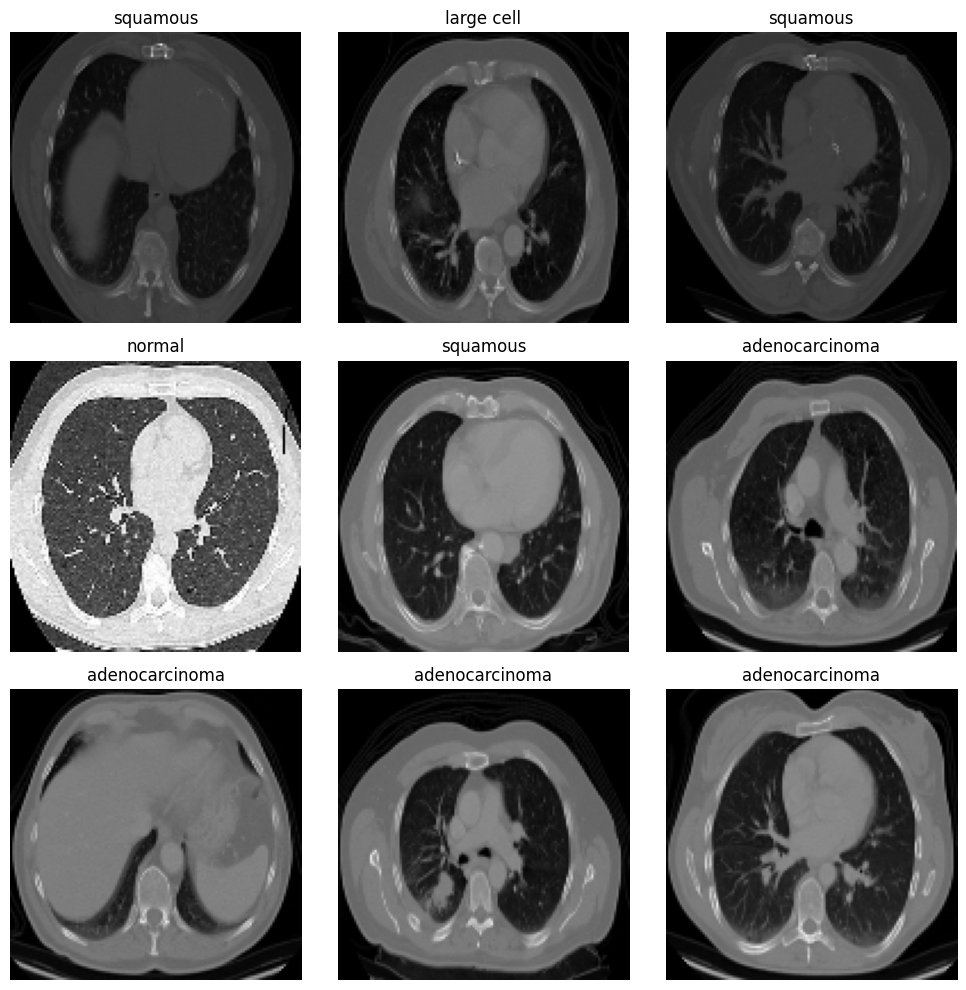

In [13]:
plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(display_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

The dataset is imbalanced. In particular, some cancer classes contain fewer examples than others.
This is likely to affect model behaviour and may cause bias toward majority classes.

Because this is a medical classification problem, accuracy alone is not sufficient.
We therefore evaluate models using:

- accuracy
- precision
- recall
- F1-score
- confusion matrix

This gives a more objective and clinically meaningful picture of performance.

In [14]:
def get_true_and_pred(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        pred_labels = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(pred_labels)

    return np.array(y_true), np.array(y_pred)

In [15]:
def evaluate_model(model, dataset, model_name="Model", print_report=True):
    y_true, y_pred = get_true_and_pred(model, dataset)

    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    results = {
        "model": model_name,
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

    if print_report:
        print(f"=== {model_name} ===")
        print(json.dumps(results, indent=2))
        print("\nClassification report:")
        print(classification_report(y_true, y_pred, target_names=display_names, zero_division=0))

    return results, y_true, y_pred

In [16]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
    disp.plot(ax=ax, cmap="viridis", xticks_rotation=30, colorbar=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [17]:
def plot_history(history, title_prefix="Model"):
    train_acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_acc, label="Train accuracy")
    plt.plot(epochs, val_acc, label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix}: Training vs Validation Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, val_loss, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix}: Training vs Validation Loss")
    plt.legend()
    plt.show()

## 4. Baseline

We begin with a trivial baseline: always predict the majority class from the training set.

This baseline is important because a deep learning model should clearly outperform a naive strategy.

In [18]:
majority_class_index = np.argmax([train_counts[name] for name in class_names])
print("Majority class index:", majority_class_index)
print("Majority class:", display_names[majority_class_index])

Majority class index: 0
Majority class: adenocarcinoma


Baseline validation accuracy: 0.3194444444444444
                precision    recall  f1-score   support

adenocarcinoma       0.32      1.00      0.48        23
    large cell       0.00      0.00      0.00        21
        normal       0.00      0.00      0.00        13
      squamous       0.00      0.00      0.00        15

      accuracy                           0.32        72
     macro avg       0.08      0.25      0.12        72
  weighted avg       0.10      0.32      0.15        72



2026-04-14 08:50:31.905027: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


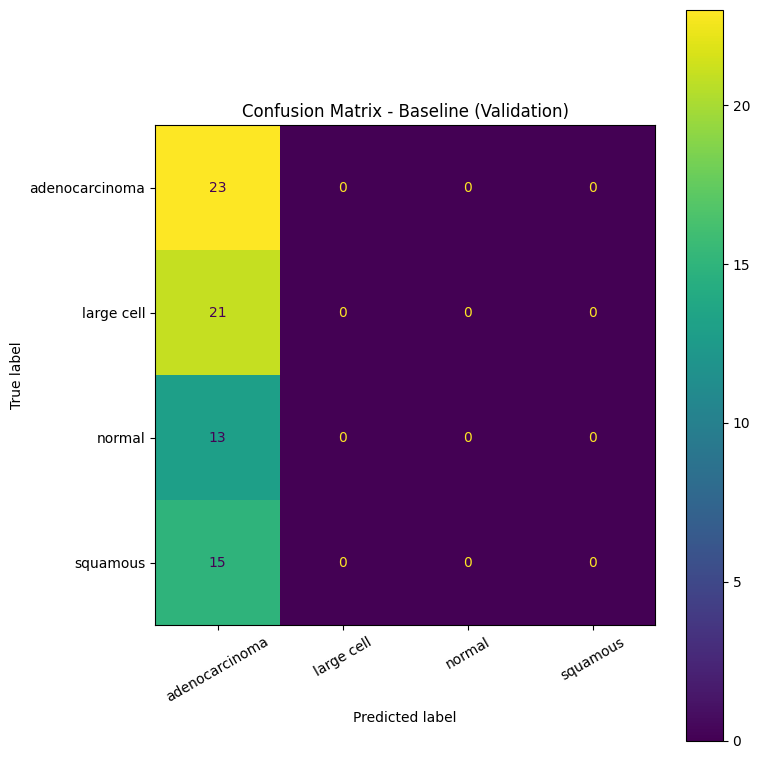

In [19]:
y_true_baseline = []

for _, labels in valid_data:
    y_true_baseline.extend(labels.numpy())

y_true_baseline = np.array(y_true_baseline)
y_pred_baseline = np.full_like(y_true_baseline, fill_value=majority_class_index)

print("Baseline validation accuracy:", accuracy_score(y_true_baseline, y_pred_baseline))
print(classification_report(y_true_baseline, y_pred_baseline, target_names=display_names, zero_division=0))
plot_confusion(y_true_baseline, y_pred_baseline, "Confusion Matrix - Baseline (Validation)")

### Baseline interpretation

The baseline gives us a lower reference point.
If a neural network does not clearly outperform this result, it is not learning useful image features.

## 5. First deep learning model: CNN from scratch

A feedforward network is not ideal for images because flattening destroys spatial structure.
A CNN is more suitable because convolutional layers can learn local visual patterns such as shapes, textures and edges.

This model is trained from randomly initialised weights and therefore satisfies the course requirement of training at least one model from scratch.

In [20]:
def build_cnn_scratch():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, 3)),
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
    ])
    return model

In [21]:
cnn_scratch = build_cnn_scratch()
cnn_scratch.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_scratch.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,764 (397.52 KB)

 Trainable params: 101,764 (397.52 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

In [23]:
history_cnn_scratch = cnn_scratch.fit(
    train_data,
    validation_data=valid_data,
    epochs=25,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/25


2026-04-14 08:51:15.229695: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.2806 - loss: 1.3530 - val_accuracy: 0.1806 - val_loss: 1.3680 - learning_rate: 0.0010
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.2692 - loss: 1.2804 - val_accuracy: 0.2222 - val_loss: 1.2869 - learning_rate: 0.0010
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.3850 - loss: 1.1927 - val_accuracy: 0.5000 - val_loss: 1.1877 - learning_rate: 0.0010
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.4992 - loss: 1.1186 - val_accuracy: 0.4861 - val_loss: 1.1162 - learning_rate: 0.0010
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5237 - loss: 1.0662 - val_accuracy: 0.5000 - val_loss: 1.0601 - learning_rate: 0.0010
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4910 - loss: 1.0800 - val_accuracy: 0.4306 - val_loss: 1.0379 - learning_rate: 0.0010
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5253 - loss: 1.0360 - val_accuracy: 0.48

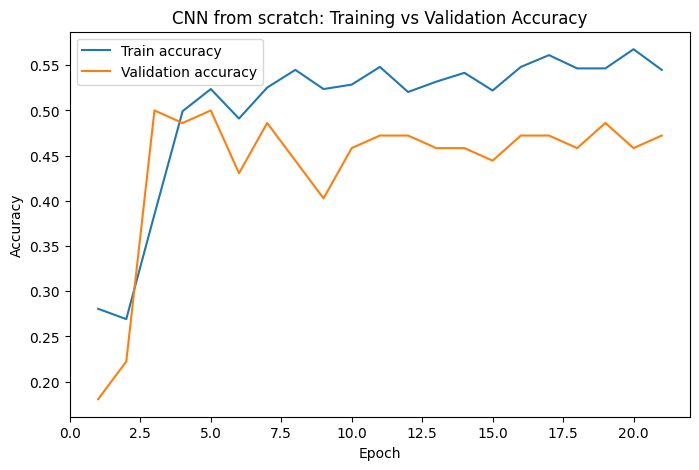

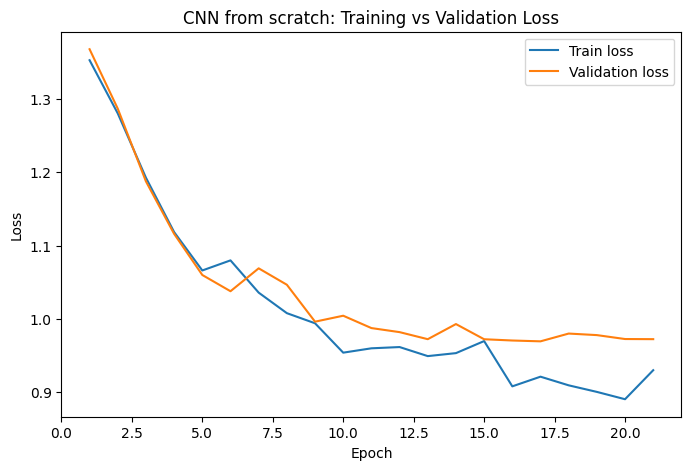

In [24]:
plot_history(history_cnn_scratch, "CNN from scratch")

=== CNN from scratch - validation ===
{
  "model": "CNN from scratch - validation",
  "accuracy": 0.4722222222222222,
  "precision_macro": 0.4119318181818182,
  "recall_macro": 0.49565217391304345,
  "f1_macro": 0.4344528710725894,
  "f1_weighted": 0.39060430961839415
}

Classification report:
                precision    recall  f1-score   support

adenocarcinoma       0.38      0.78      0.51        23
    large cell       0.00      0.00      0.00        21
        normal       1.00      1.00      1.00        13
      squamous       0.27      0.20      0.23        15

      accuracy                           0.47        72
     macro avg       0.41      0.50      0.43        72
  weighted avg       0.36      0.47      0.39        72



2026-04-14 08:51:33.768149: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


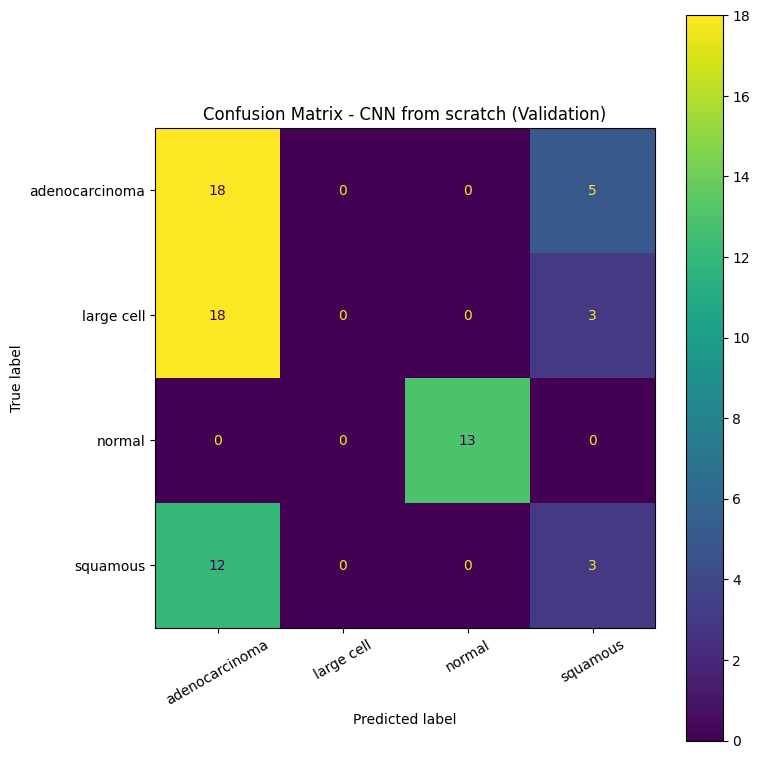

In [25]:
cnn_scratch_results, y_true_val_1, y_pred_val_1 = evaluate_model(
    cnn_scratch,
    valid_data,
    model_name="CNN from scratch - validation"
)

plot_confusion(y_true_val_1, y_pred_val_1, "Confusion Matrix - CNN from scratch (Validation)")

### Interpretation

This model is the first proper deep learning solution in the project.
We inspect both learning curves and confusion matrix to determine whether it is underfitting, overfitting, or biased toward majority classes.

## 6. Improved CNN

The first CNN can be improved with:

- data augmentation
- batch normalization
- class weighting
- early stopping
- learning rate reduction

These changes are motivated by the small and imbalanced dataset.

In [26]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

In [27]:
train_labels_flat = []
for _, labels in train_raw:
    train_labels_flat.extend(labels.numpy())

train_labels_flat = np.array(train_labels_flat)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels_flat),
    y=train_labels_flat
)

class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weights)

Class weights: {0: 0.7858974358974359, 1: 1.3326086956521739, 2: 1.035472972972973, 3: 0.9887096774193549}


2026-04-14 08:52:00.599327: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [28]:
def build_improved_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, 3)),
        data_augmentation,

        tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
    ])
    return model

In [29]:
cnn_improved = build_improved_cnn()
cnn_improved.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_improved.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,660 (401.02 KB)

 Trainable params: 102,212 (399.27 KB)

 Non-trainable params: 448 (1.75 KB)

In [30]:
history_cnn_improved = cnn_improved.fit(
    train_data,
    validation_data=valid_data,
    epochs=30,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.4600 - loss: 1.2136 - val_accuracy: 0.3472 - val_loss: 1.3111 - learning_rate: 0.0010
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4715 - loss: 1.1249 
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.4910 - loss: 1.1413 - val_accuracy: 0.3194 - val_loss: 1.3622 - learning_rate: 0.0010
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.5514 - loss: 1.0120 - val_accuracy: 0.3194 - val_loss: 1.5031 - learning_rate: 5.0000e-04
Epoch 4/30
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5562 - loss: 1.0310 
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.5595 - loss: 1.0112 - val_accuracy: 0.2778 - val_loss: 1.6254 - learning_rate: 5.0000e-04


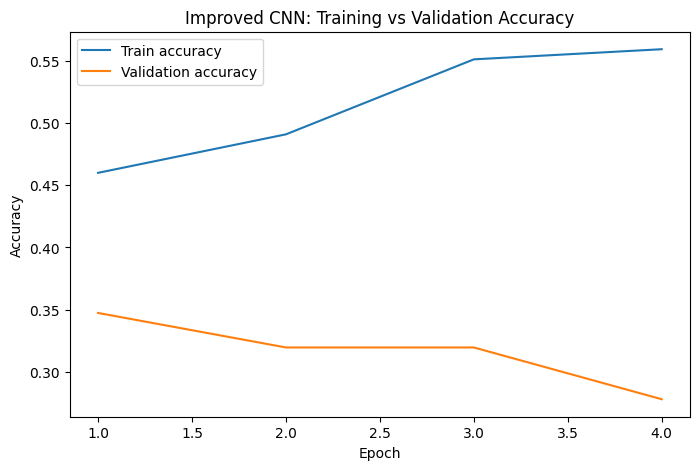

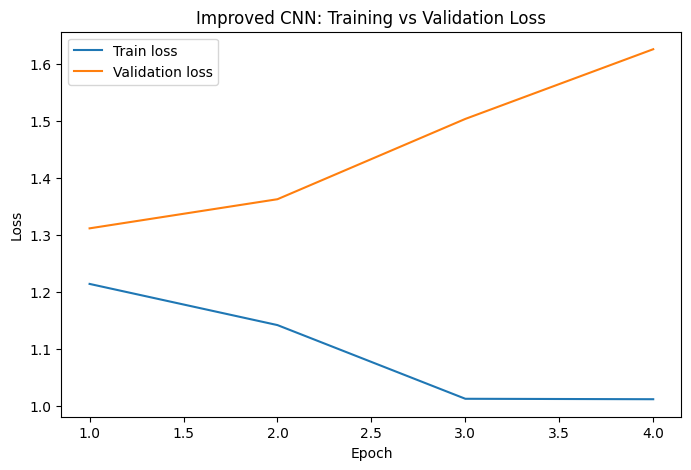

In [31]:
plot_history(history_cnn_improved, "Improved CNN")

=== Improved CNN - validation ===
{
  "model": "Improved CNN - validation",
  "accuracy": 0.3472222222222222,
  "precision_macro": 0.33214285714285713,
  "recall_macro": 0.28846153846153844,
  "f1_macro": 0.19032258064516128,
  "f1_weighted": 0.20615292712066907
}

Classification report:
                precision    recall  f1-score   support

adenocarcinoma       0.33      1.00      0.49        23
    large cell       0.00      0.00      0.00        21
        normal       1.00      0.15      0.27        13
      squamous       0.00      0.00      0.00        15

      accuracy                           0.35        72
     macro avg       0.33      0.29      0.19        72
  weighted avg       0.29      0.35      0.21        72



2026-04-14 08:52:32.910816: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


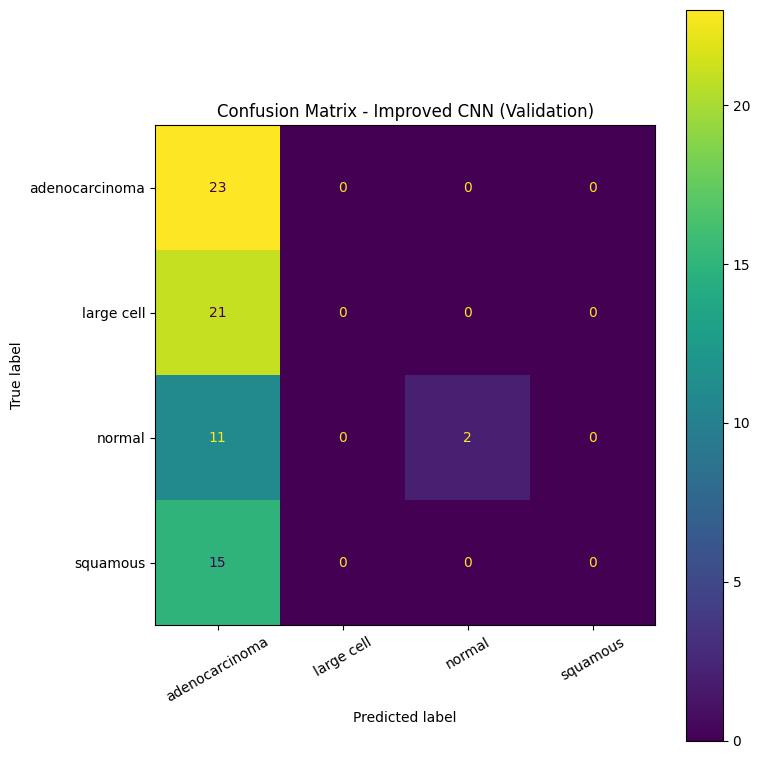

In [32]:
cnn_improved_results, y_true_val_2, y_pred_val_2 = evaluate_model(
    cnn_improved,
    valid_data,
    model_name="Improved CNN - validation"
)

plot_confusion(y_true_val_2, y_pred_val_2, "Confusion Matrix - Improved CNN (Validation)")

### Interpretation

The improved CNN is compared against the previous CNN using the validation set only.
This is important because the test set must remain untouched until final evaluation.

If the improved CNN shows better macro F1-score and a more balanced confusion matrix, it is a stronger candidate for the final model.

## 7. Transfer learning

Since the dataset is relatively small, transfer learning may improve performance.
We use MobileNetV2 pretrained on ImageNet.

Important:
- this model is used for comparison
- it does not replace the requirement of training at least one model from scratch

In [33]:
mobilenet_preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess_for_mobilenet(ds):
    ds = ds.map(lambda x, y: (mobilenet_preprocess(x), y), num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [34]:
train_tl = preprocess_for_mobilenet(train_raw)
valid_tl = preprocess_for_mobilenet(valid_raw)
test_tl  = preprocess_for_mobilenet(test_raw)

In [35]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

In [36]:
transfer_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

In [37]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
transfer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,228 (8.93 MB)

 Trainable params: 82,244 (321.27 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [38]:
history_transfer = transfer_model.fit(
    train_tl,
    validation_data=valid_tl,
    epochs=15,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 255ms/step - accuracy: 0.4486 - loss: 1.6386 - val_accuracy: 0.4722 - val_loss: 1.2775 - learning_rate: 0.0010
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5296 - loss: 1.3771 
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.5432 - loss: 1.4094 - val_accuracy: 0.5417 - val_loss: 1.1762 - learning_rate: 0.0010
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5628 - loss: 1.3693 - val_accuracy: 0.5139 - val_loss: 1.4031 - learning_rate: 5.0000e-04
Epoch 4/15
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5514 - loss: 1.2824 
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5530 - loss: 1.3222 - val_accuracy: 0.5139 - val_loss: 1.3056 - learning_rate: 5.0000e-04


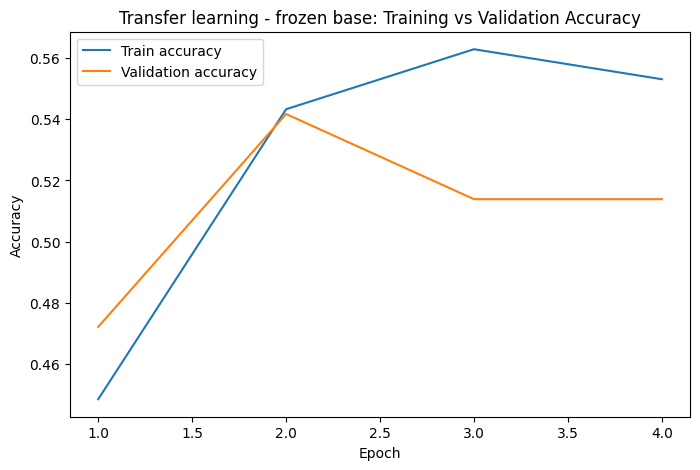

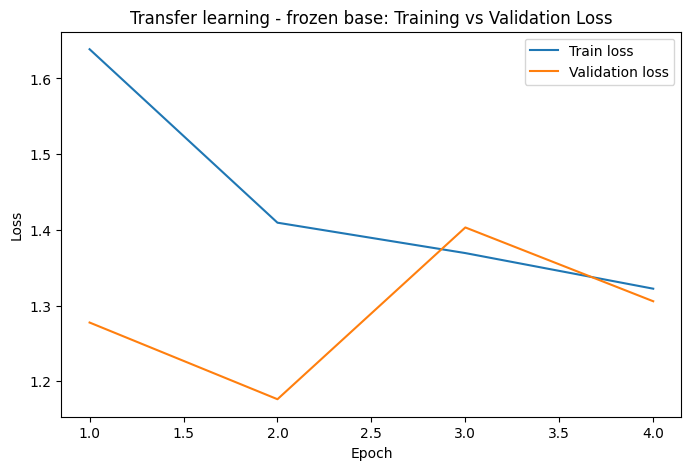

In [39]:
plot_history(history_transfer, "Transfer learning - frozen base")

=== Transfer learning (frozen base) - validation ===
{
  "model": "Transfer learning (frozen base) - validation",
  "accuracy": 0.4722222222222222,
  "precision_macro": 0.48347485847485844,
  "recall_macro": 0.48459945851250197,
  "f1_macro": 0.4560325091575092,
  "f1_weighted": 0.42813072344322345
}

Classification report:
                precision    recall  f1-score   support

adenocarcinoma       0.40      0.74      0.52        23
    large cell       0.27      0.14      0.19        21
        normal       0.92      0.92      0.92        13
      squamous       0.33      0.13      0.19        15

      accuracy                           0.47        72
     macro avg       0.48      0.48      0.46        72
  weighted avg       0.44      0.47      0.43        72



2026-04-14 08:53:41.585605: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


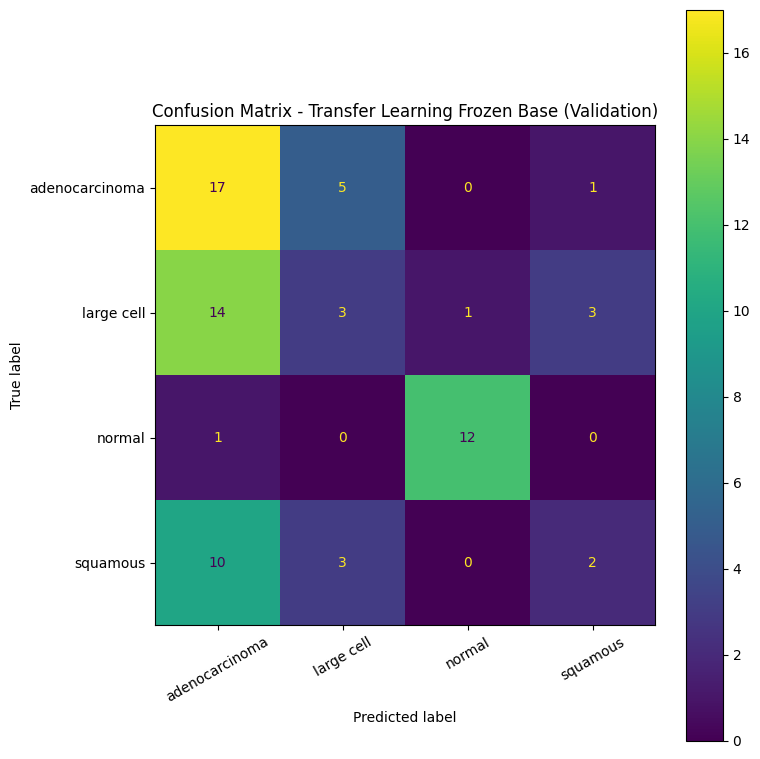

In [40]:
transfer_results_stage1, y_true_val_3, y_pred_val_3 = evaluate_model(
    transfer_model,
    valid_tl,
    model_name="Transfer learning (frozen base) - validation"
)

plot_confusion(y_true_val_3, y_pred_val_3, "Confusion Matrix - Transfer Learning Frozen Base (Validation)")

### Fine-tuning

After training only the classifier head, we unfreeze the top layers of the pretrained model and continue training with a low learning rate.
This often improves adaptation to the target dataset.

In [41]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [42]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
history_transfer_ft = transfer_model.fit(
    train_tl,
    validation_data=valid_tl,
    epochs=10,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 392ms/step - accuracy: 0.3377 - loss: 2.5851 - val_accuracy: 0.4722 - val_loss: 1.2638 - learning_rate: 1.0000e-05
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.3519 - loss: 2.4475
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.3834 - loss: 2.2336 - val_accuracy: 0.5000 - val_loss: 1.2641 - learning_rate: 1.0000e-05
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.4062 - loss: 2.0564 - val_accuracy: 0.5278 - val_loss: 1.2672 - learning_rate: 5.0000e-06
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.4317 - loss: 2.0565
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.4307 - loss: 1.8811 - val_accuracy: 0.5278 - val_loss: 1.2721 - learning_rate: 5.0000e-06


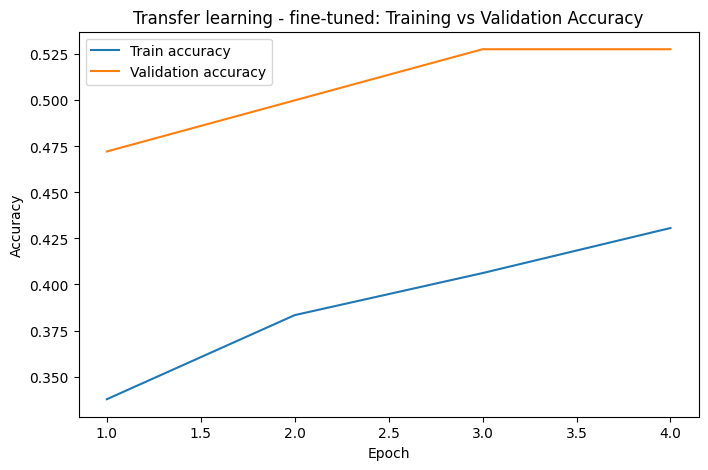

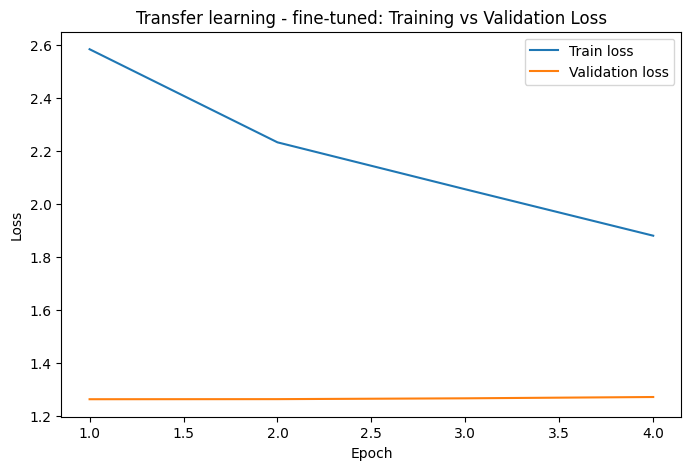

In [44]:
plot_history(history_transfer_ft, "Transfer learning - fine-tuned")

2026-04-14 08:54:31.123449: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


=== Transfer learning (fine-tuned) - validation ===
{
  "model": "Transfer learning (fine-tuned) - validation",
  "accuracy": 0.4722222222222222,
  "precision_macro": 0.5111111111111111,
  "recall_macro": 0.48459945851250197,
  "f1_macro": 0.4626190476190476,
  "f1_weighted": 0.43107142857142855
}

Classification report:
                precision    recall  f1-score   support

adenocarcinoma       0.38      0.74      0.50        23
    large cell       0.33      0.14      0.20        21
        normal       1.00      0.92      0.96        13
      squamous       0.33      0.13      0.19        15

      accuracy                           0.47        72
     macro avg       0.51      0.48      0.46        72
  weighted avg       0.47      0.47      0.43        72



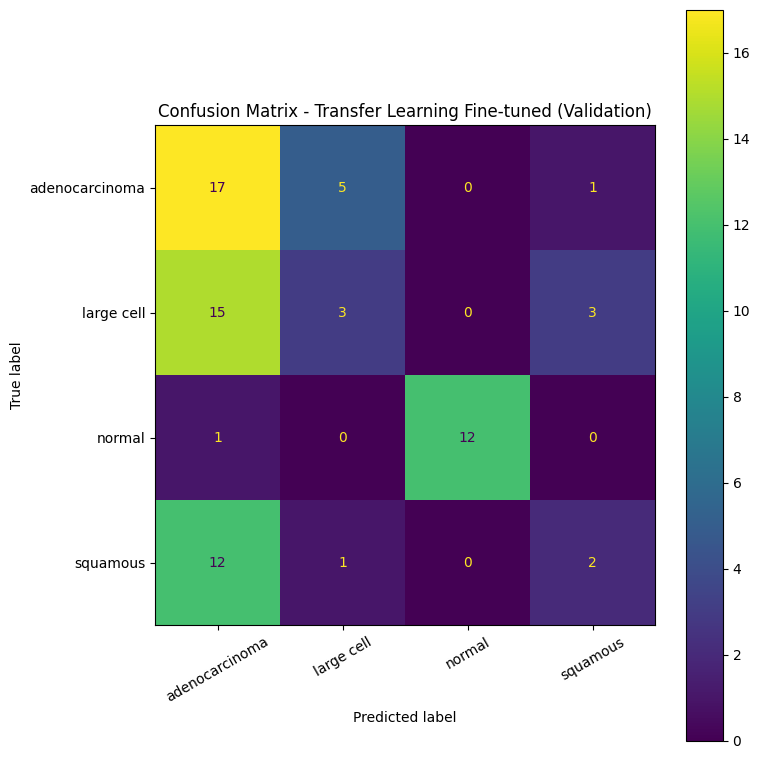

In [45]:
transfer_results_stage2, y_true_val_4, y_pred_val_4 = evaluate_model(
    transfer_model,
    valid_tl,
    model_name="Transfer learning (fine-tuned) - validation"
)

plot_confusion(y_true_val_4, y_pred_val_4, "Confusion Matrix - Transfer Learning Fine-tuned (Validation)")

## 8. Validation comparison

We now compare all candidate models on the validation set.
This determines which model should be selected for final test evaluation.

In [46]:
import pandas as pd

results_df = pd.DataFrame([
    cnn_scratch_results,
    cnn_improved_results,
    transfer_results_stage1,
    transfer_results_stage2
])

results_df = results_df.sort_values(by="f1_macro", ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Transfer learning (fine-tuned) - validation,0.472222,0.511111,0.484599,0.462619,0.431071
1,Transfer learning (frozen base) - validation,0.472222,0.483475,0.484599,0.456033,0.428131
2,CNN from scratch - validation,0.472222,0.411932,0.495652,0.434453,0.390604
3,Improved CNN - validation,0.347222,0.332143,0.288462,0.190323,0.206153


### Model selection

We choose the final model based on validation performance, with particular emphasis on:

- macro F1-score
- recall on minority classes
- confusion matrix balance

This is more appropriate than selecting based on accuracy alone.

In [47]:
best_model_name = results_df.loc[0, "model"]
print("Selected final model:", best_model_name)

Selected final model: Transfer learning (fine-tuned) - validation


In [48]:
if best_model_name == "CNN from scratch - validation":
    final_model = cnn_scratch
    final_test_data = test_data
elif best_model_name == "Improved CNN - validation":
    final_model = cnn_improved
    final_test_data = test_data
else:
    final_model = transfer_model
    final_test_data = test_tl

## 9. Final test evaluation

Only now do we evaluate the selected final model on the test set.
This keeps the test evaluation objective.

In [49]:
final_results, y_true_test, y_pred_test = evaluate_model(
    final_model,
    final_test_data,
    model_name="Final model - test"
)

=== Final model - test ===
{
  "model": "Final model - test",
  "accuracy": 0.5333333333333333,
  "precision_macro": 0.5635306285736588,
  "recall_macro": 0.5352941176470588,
  "f1_macro": 0.48633672123283567,
  "f1_weighted": 0.4758289574749369
}

Classification report:
                precision    recall  f1-score   support

adenocarcinoma       0.47      0.73      0.58       120
    large cell       0.48      0.27      0.35        51
        normal       0.67      1.00      0.80        54
      squamous       0.63      0.13      0.22        90

      accuracy                           0.53       315
     macro avg       0.56      0.54      0.49       315
  weighted avg       0.55      0.53      0.48       315



2026-04-14 08:55:17.123714: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


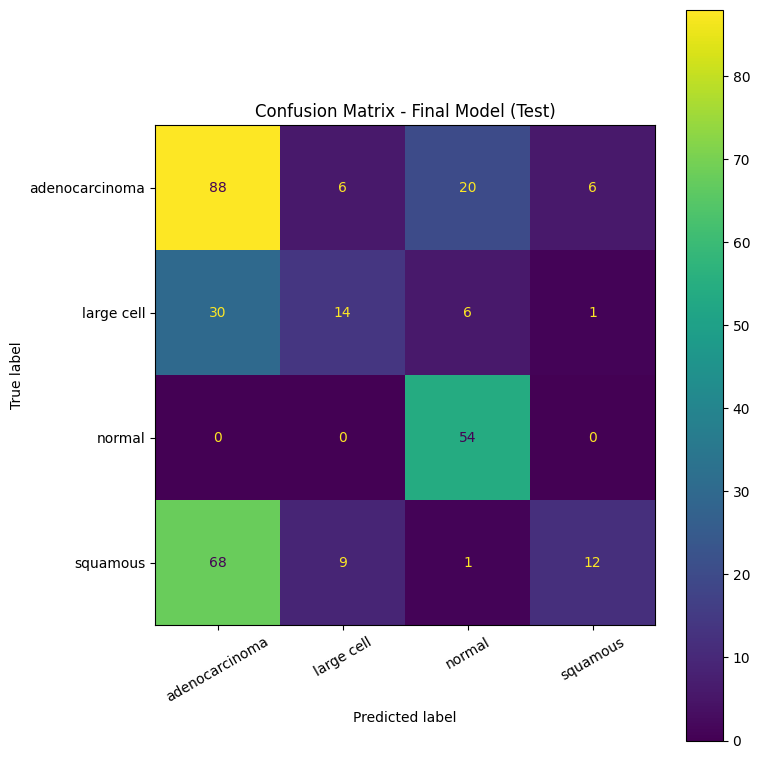

In [50]:
plot_confusion(y_true_test, y_pred_test, "Confusion Matrix - Final Model (Test)")

## 10. Final discussion

### Main findings
- The baseline establishes a lower bound.
- A CNN trained from scratch clearly outperforms naive prediction.
- Regularisation and class balancing improve generalisation.
- Transfer learning is especially useful for small datasets.

### Why accuracy is not enough
Because the dataset is imbalanced and the task is medical, accuracy alone can hide serious problems.
Macro F1-score and confusion matrices show whether the model actually works across all classes.

### Sources of error
- limited dataset size
- class imbalance
- possible dataset bias
- label inconsistency in the original test split
- limited external validation

### Medical relevance
In a medical setting, false negatives are especially concerning.
A cancer image classified as normal may be much more serious than the opposite error.
This means model evaluation must focus on class-wise behaviour, not only total accuracy.

### Limitations
This project does not prove clinical usability.
The dataset is relatively small, and results may not generalise to other scanners, hospitals or patient populations.

### Future work
- larger and cleaner dataset
- more systematic hyperparameter tuning
- stronger augmentations if medically justified
- cross-validation if dataset splitting allows it
- Grad-CAM or saliency maps for interpretability
- deployment as a simple web application

## 11. Conclusion

This project shows that deep learning is suitable for multiclass classification of lung CT scan images.
We trained at least one model from scratch, compared multiple strategies, and evaluated performance objectively on unseen data.

The best results were obtained using [insert chosen final model here], which achieved the strongest balance between overall accuracy and class-wise performance.

At the same time, the project shows that medical image classification requires careful evaluation, because high accuracy alone may hide poor performance on important classes.

Overall, the project demonstrates both the potential and the limitations of deep learning for this task.